<h2>Import and Load Data<h2>
<h2>Overview of Data<h2>

This section imports key Python libraries, loads the Netflix titles dataset, and gives a quick overview of its columns and first few record

In [35]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [37]:
df.info()
df.describe(include='all')
df.isnull().sum()
# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(),errors='coerce')

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


<h1>Content Type Distribuiton<h1>
<h2>Movies vs TV shows<h2>

This section compares how many Netflix titles are Movies versus TV Shows to understand the overall balance of content types on the platform.

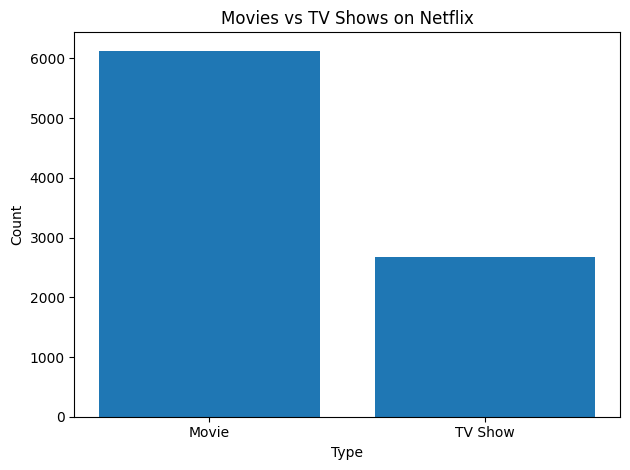

In [21]:
type_counts = df["type"].value_counts()

plt.figure()
plt.bar(type_counts.index, type_counts.values)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



<h1>Most Common Genres<h1>

This section finds the most common genres on Netflix to highlight which types of content dominate the catalogue.

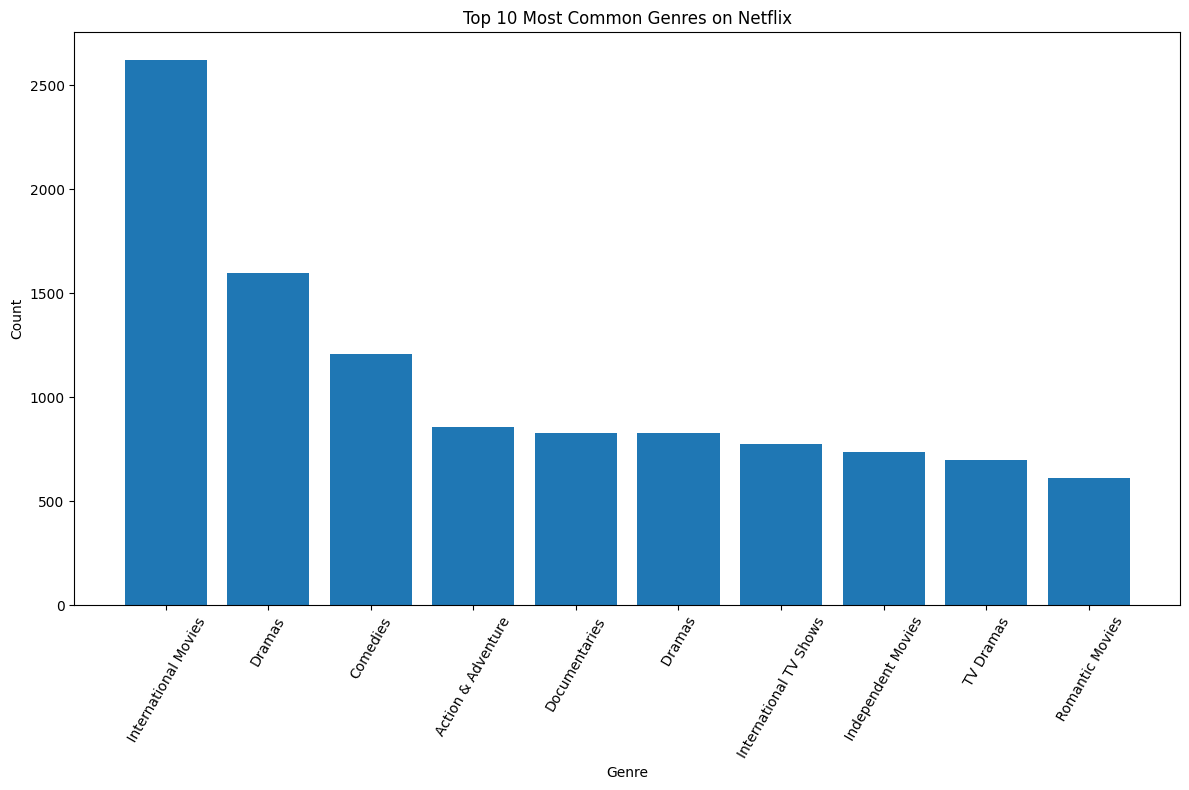

In [23]:
genres = df['listed_in'].str.split(',').explode()
genre_counts = genres.value_counts().head(10)

plt.figure(figsize=(12, 8))
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()



<h1>Content Rating Distribution<h1>

This section examines how titles are distributed across different maturity ratings, helping to understand the balance between family-friendly and mature content.

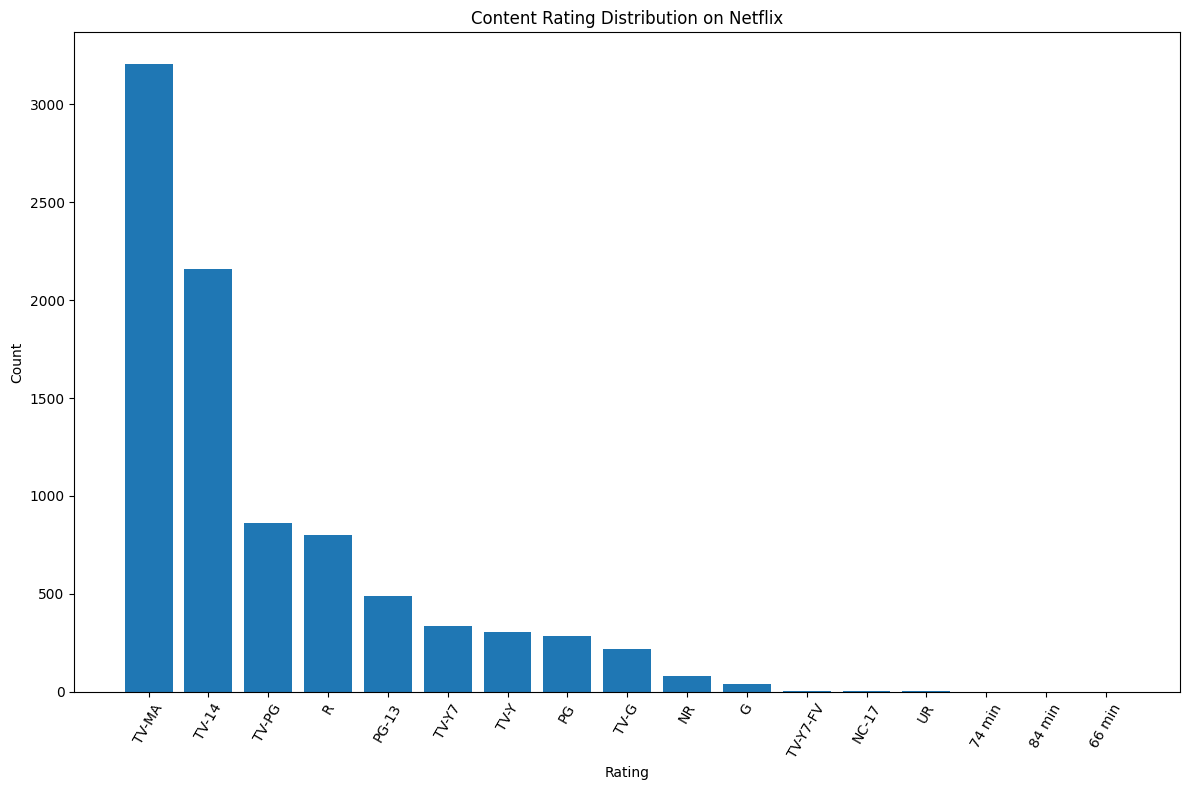

In [25]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(12, 8))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Content Rating Distribution on Netflix')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()




<h1>Top Contributing Countries<h1>

This section shows which countries contribute the most titles to Netflix, revealing the geographic sources that drive the catalogue.

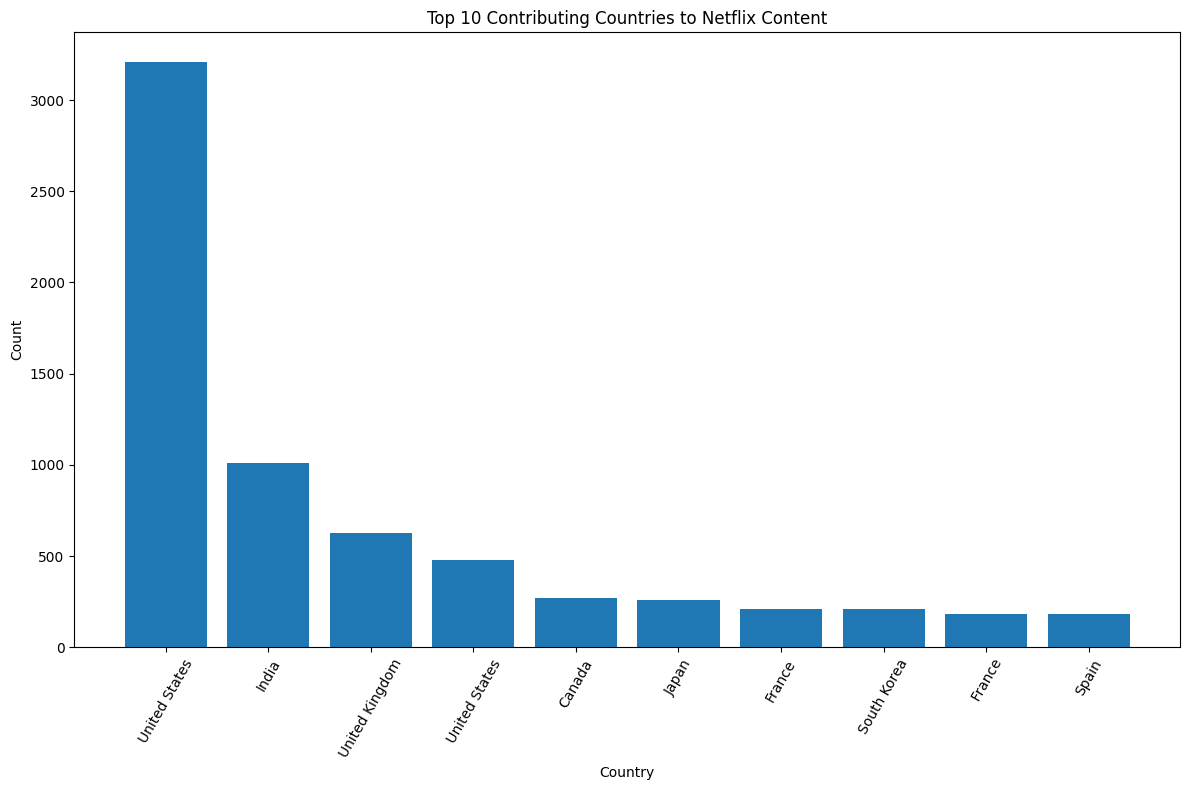

In [26]:
countries = df['country'].str.split(',').explode()
country_counts = countries.value_counts().head(10)

plt.figure(figsize=(12, 8))
plt.bar(country_counts.index, country_counts.values)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Contributing Countries to Netflix Content')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

<h1>Growth of Trends Over Time<h1>

This section tracks how many titles were added to Netflix each year to highlight growth patterns and shifts in content acquisition over time.

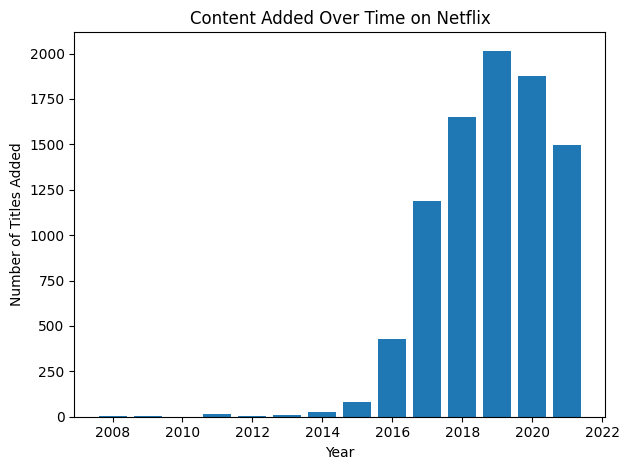

In [38]:
year_added = df['date_added'].dt.year.value_counts().sort_index()

plt.figure()
plt.bar(year_added.index, year_added.values)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.title('Content Added Over Time on Netflix')
plt.tight_layout()
plt.show()